#### Milestone 1

##### Loading necessary libraries

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

##### Loading excel file (dataset)

In [49]:
file_path = "nationaldatabaseofchildcareprices.xlsx"

##### Checking what sheets exist

In [50]:
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)

Available sheets: ['nationaldatabaseofchildcare']


##### Reading the main sheet (replacing with correct name if needed)

In [51]:
df = pd.read_excel(file_path, sheet_name=xls.sheet_names[0])

##### Displaying first few rows

In [52]:
df.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


##### Displaying summarry information about dataset

In [53]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Columns: 227 entries, State_Name to _75FCCPreschool_flag
dtypes: float64(159), int64(65), object(3)
memory usage: 59.9+ MB


,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,MUNR_20to64,FLFPR_20to64,FLFPR_20to64_Under6,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
count,34567.000000,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.00000,23383.000000,23383.000000
mean,30388.132786,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,...,106.759749,1.153359,104.189510,1.287859,128.909289,1.792841,120.784283,1.18800,117.897482,1.294316
std,15161.015383,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,...,29.982431,0.532176,28.961701,0.696762,38.543010,0.818080,35.334666,0.58367,34.111188,0.708542
min,1001.000000,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,43.080000,1.000000,40.030000,1.000000,50.000000,1.000000,50.000000,1.00000,46.450000,1.000000
25%,18177.000000,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,85.085000,1.000000,84.255000,1.000000,100.830000,1.000000,95.850000,1.00000,95.000000,1.000000
50%,29177.000000,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,...,100.250000,1.000000,99.650000,1.000000,123.150000,2.000000,115.000000,1.00000,112.500000,1.000000
75%,45081.000000,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,...,124.950000,1.000000,120.200000,1.000000,146.950000,3.000000,136.270000,1.00000,132.760000,1.000000
max,56045.000000,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,...,376.320000,3.000000,331.340000,3.000000,502.970000,3.000000,439.220000,3.00000,386.720000,3.000000


##### Generating basic line plot of childcare prices over time for visualization

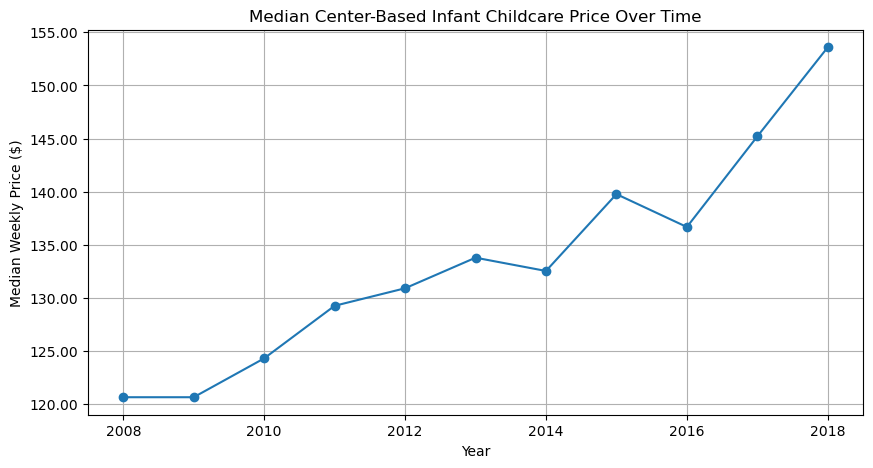

In [54]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10,5))
median_prices = df.groupby("StudyYear")["MCInfant"].median()

median_prices.plot(marker='o')
plt.title("Median Center-Based Infant Childcare Price Over Time")
plt.xlabel("Year")
plt.ylabel("Median Weekly Price ($)")
plt.grid(True)

# Format y-axis to two decimals
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.2f}')
plt.show()


##### Grouping by year

In [55]:
df.groupby("StudyYear")["MCInfant"].median().round(2)

StudyYear
2008    120.64
2009    120.64
2010    124.30
2011    129.25
2012    130.90
2013    133.78
2014    132.53
2015    139.76
2016    136.67
2017    145.20
2018    153.60
Name: MCInfant, dtype: float64

This milestone provides an initial exploratory analysis of infant childcare costs using the National Database of Childcare Prices in the United States of America.

# Summary of the Dataset, Analysis, and Findings

The dataset contains 34,566 rows and 227 columns. After reviewing the chart titled “Median Center-Based Infant Childcare Price Over Time,” it is clear that from 2008 to 2018, center-based infant childcare prices increased substantially. In 2008, the median cost was 120.64 dollars. By 2018, the median cost rose to 153.60 dollars, which is a bit more than a 27% increase over the decade.

The increase did not occur evenly every year. For example, the median price stayed the same between 2008 and 2009 (120.64 dollars). From 2010 to 2013, the cost increased from 124.30 dollars to 133.78 dollars, which is about a 7.6% rise. Then, in 2014, the median price slightly decreased from 133.78 dollars to 132.53 dollars. In 2015, it jumped again to 139.76 dollars before dropping to 136.67 dollars in 2016. During the final two years of the dataset, from 2016 to 2018, the median cost increased consistently from 136.67 dollars to 153.60 dollars.

These numbers show that raising children today is expensive, and rising childcare prices may be one reason why the birth rate has been slowing significantly. Infant care places a major financial burden on families, especially younger parents and those living in high-cost areas.

In this project, the MCInfant column was used to represent center-based infant care costs. The analysis focused on the median price across all states and counties for each year. While this provides an overall picture, it would be useful to explore how prices differ by state or county. It is reasonable to expect that childcare in large metropolitan areas costs more than in smaller towns or rural communities. It would also be valuable to understand how much of the increase is related to inflation, how much is related to policy changes, and how much is driven by supply-and-demand issues.

# Direction of Story and Message

**Story:**  
Infant childcare costs are rising over time, increasing financial pressure on American families. The key point my analysis will communicate is that infant childcare prices are steadily increasing and placing a financial burden on families.

**Key Message / Call to Action:**  
Affordable childcare is critical. Policymakers should consider programs or initiatives that help families access reasonably priced infant care.

# Target Audience

The main audience for this story includes:  
- Policymakers  
- Childcare advocacy groups  
- Community organizations focused on family and early-childhood support  

These groups can directly influence childcare affordability and availability.

# Mediums

For this project, the primary medium will be a PowerPoint presentation with line charts and clear bullet points showing the rising trends in infant care costs. PowerPoint with line charts will help audiences quickly visualize the rise in childcare costs over time. It has not yet been decided whether Tableau or Power BI will be used for visualizations, but one of them will be included. These tools will make it possible to filter the data by state, age group, or childcare type (center-based vs. family childcare). Tableau or Power BI will allow interactive filtering so policymakers can more easily compare states.  

A third medium will be a one-page policy brief. This medium will summarize the key findings, explaining why the rising cost of infant childcare is a concern, and outline the practical suggestions for policy makers to take.

# Conclusion and Policy Implications

With median infant childcare prices rising substantially over time, policymakers need to take action to help families manage these costs. As of 2025, the U.S. birth rate is slowing rapidly, and the population is aging. This can affect economic growth and the future labor force. One possible solution is to increase government funding to build more childcare centers and expand existing ones. Increasing supply could help reduce prices, create more jobs, and make it easier for families to decide to have more children.
